# Sales Performance & Business Insights Analysis

## Objective
This project aims to analyze sales performance, customer behavior, and regional trends in order to generate business insights and strategic recommendations.
    

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')

df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Dataset Overview

The dataset contains transactional sales data including customer information, product categories, sales, profit, discounts, and regional performance.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [9]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [11]:
df['Year'] = df['Order Date'].dt.year

df['Month'] = df['Order Date'].dt.month_name()

# Executive KPI Analysis

This section evaluates the overall business performance through key financial and operational metrics.

In [12]:
total_sales = df['Sales'].sum()

print("Total Revenue:", total_sales)

Total Revenue: 2297200.8603000003


In [13]:
total_profit = df['Profit'].sum()

print("Total Profit:", total_profit)

Total Profit: 286397.0217


In [14]:
profit_margin = (total_profit / total_sales) * 100

print("Profit Margin:", profit_margin)

Profit Margin: 12.467217240315604


In [15]:
total_orders = df['Order ID'].nunique()

print("Total Orders:", total_orders)

Total Orders: 5009


In [16]:
total_customers = df['Customer ID'].nunique()

print("Total Customers:", total_customers)

Total Customers: 793


In [17]:
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()

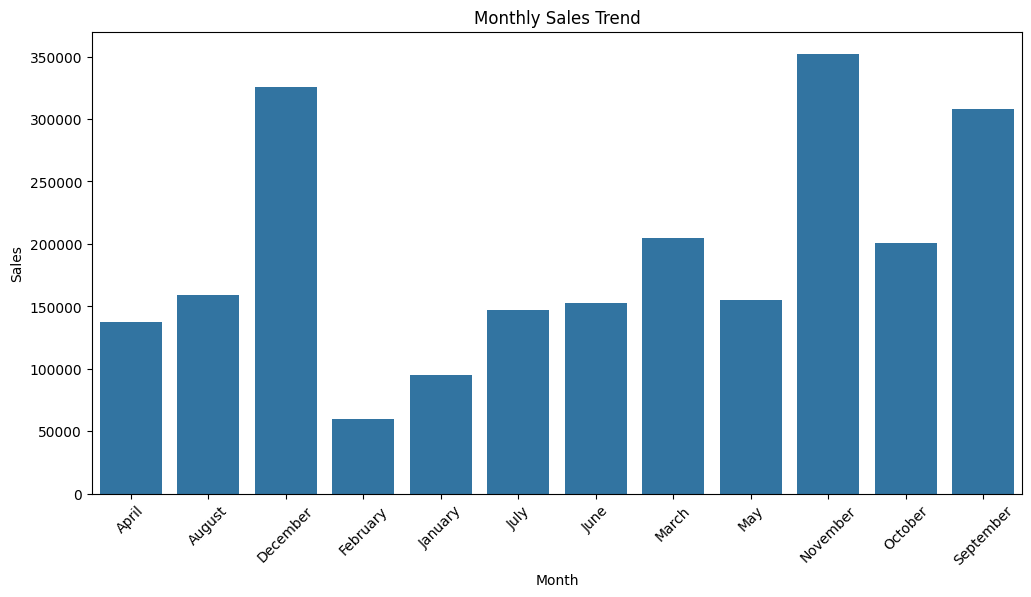

In [18]:
plt.figure(figsize=(12,6))

sns.barplot(x='Month', y='Sales', data=monthly_sales)

plt.title('Monthly Sales Trend')

plt.xticks(rotation=45)

plt.show()

In [19]:
category_sales = df.groupby('Category')['Sales'].sum().reset_index()

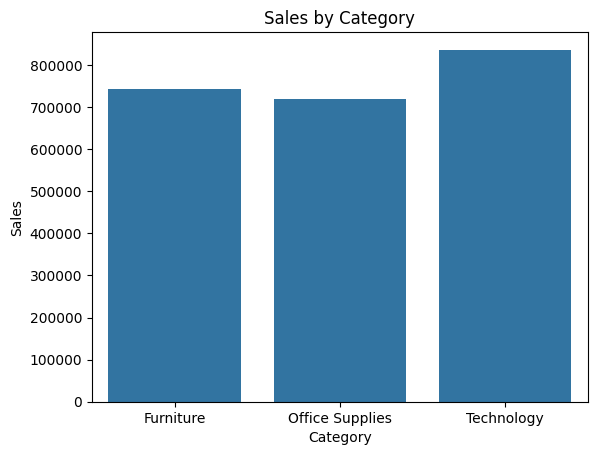

In [20]:
sns.barplot(x='Category', y='Sales', data=category_sales)

plt.title('Sales by Category')

plt.show()

In [21]:
region_sales = df.groupby('Region')['Sales'].sum().reset_index()

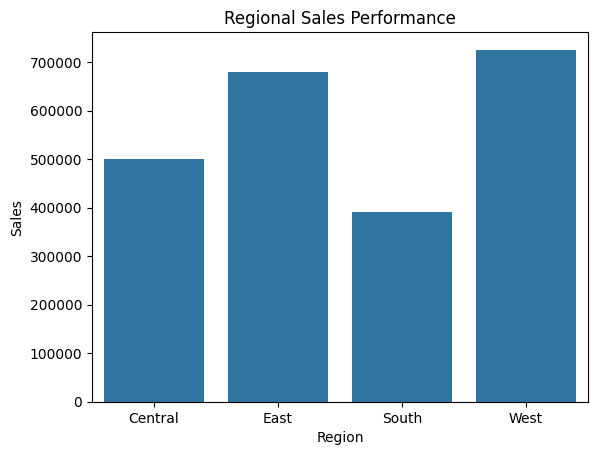

In [22]:
sns.barplot(x='Region', y='Sales', data=region_sales)

plt.title('Regional Sales Performance')

plt.show()

# Final Recommendations

- Focus retention efforts on high-profit customer segments.
- Reduce excessive discounting on low-profit products.
- Invest more heavily in high-performing regions.
- Develop seasonal campaigns during peak sales periods.
- Improve profitability analysis for underperforming categories.

# Executive KPI Analysis

In [23]:
total_sales = df['Sales'].sum()
print(f"Total Revenue: ${total_sales:,.2f}")

Total Revenue: $2,297,200.86


In [24]:
total_profit = df['Profit'].sum()
print(f"Total Profit: ${total_profit:,.2f}")

Total Profit: $286,397.02


In [25]:
profit_margin = (total_profit / total_sales) * 100
print(f"Profit Margin: {profit_margin:.2f}%")

Profit Margin: 12.47%


In [26]:
total_orders = df['Order ID'].nunique()
print(f"Total Orders: {total_orders}")

Total Orders: 5009


In [27]:
total_customers = df['Customer ID'].nunique()
print(f"Total Customers: {total_customers}")

Total Customers: 793


In [28]:
avg_order_value = df.groupby('Order ID')['Sales'].sum().mean()
print(f"Average Order Value: ${avg_order_value:,.2f}")

Average Order Value: $458.61


# Executive Summary
The company generated approximately $2.3 million in total revenue, resulting in $286 thousand in profit and achieving a profit margin of 12.47%. This indicates a profitable business operation with moderate efficiency in converting sales into profit.
A total of 5,009 orders were placed by 793 unique customers, suggesting a relatively high level of customer engagement and repeat purchasing behavior.
The average order value of $458.61 demonstrates strong transaction sizes, indicating that customers are purchasing multiple items or higher-value products per order.
While overall financial performance appears healthy, further analysis is required to identify the most profitable products, regions, and customer segments, as well as areas where profitability can be improved.


# Sales Trend Analysis

In [29]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Year'] = df['Order Date'].dt.year

df['Month'] = df['Order Date'].dt.month_name()

In [30]:
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()

monthly_sales

,Month,Sales
0,April,137762.1286
1,August,159044.0630
2,December,325293.5035
3,February,59751.2514
4,January,94924.8356
5,July,147238.0970
6,June,152718.6793
7,March,205005.4888
8,May,155028.8117
9,November,352461.0710


In [32]:
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

monthly_sales['Month'] = pd.Categorical(
    monthly_sales['Month'],
    categories=month_order,
    ordered=True
)

monthly_sales = monthly_sales.sort_values('Month')

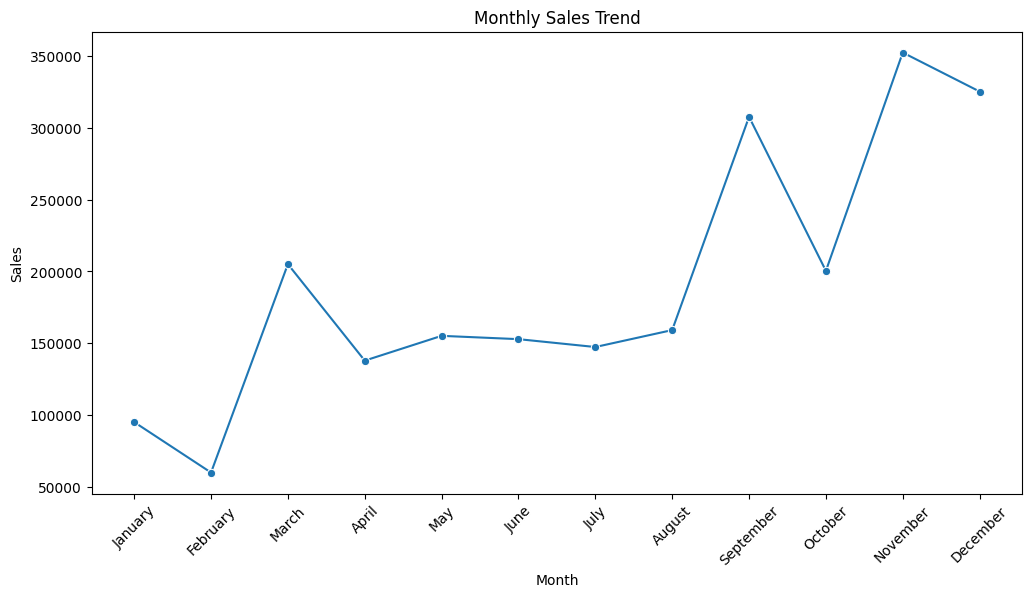

In [33]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_sales,
    x='Month',
    y='Sales',
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xticks(rotation=45)

plt.show()

## Key Findings

- November recorded the highest sales performance throughout the year.
- February generated the lowest sales volume.
- Sales increased significantly during the fourth quarter (Q4).
- The business demonstrates a clear seasonal sales pattern.

## Executive Insight

The business demonstrates a strong seasonal sales pattern, with peak performance concentrated in the fourth quarter of the year. November represents the highest revenue-generating month, while February shows the weakest performance. This suggests significant opportunities for seasonal campaign optimization, inventory planning, and targeted marketing efforts to maximize annual revenue.

In [34]:
category_performance = df.groupby('Category').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()

category_performance

,Category,Sales,Profit
0,Furniture,741999.7953,18451.2728
1,Office Supplies,719047.0320,122490.8008
2,Technology,836154.0330,145454.9481


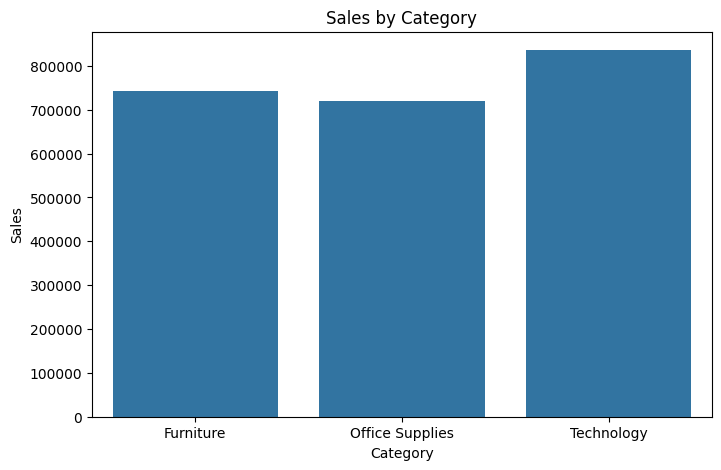

In [35]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=category_performance,
    x='Category',
    y='Sales'
)

plt.title('Sales by Category')

plt.show()

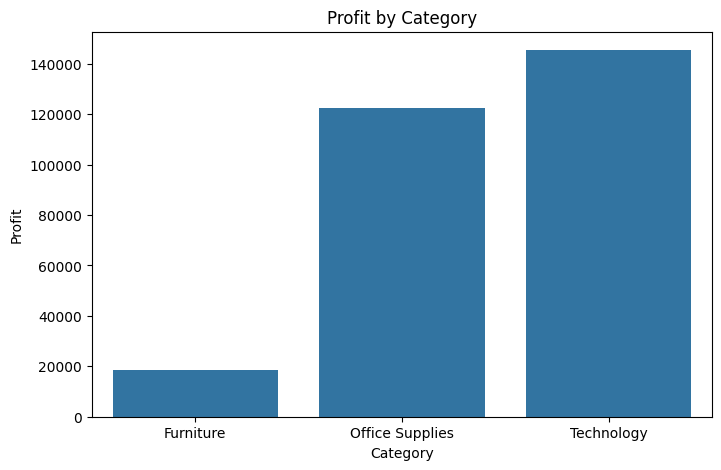

In [36]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=category_performance,
    x='Category',
    y='Profit'
)

plt.title('Profit by Category')

plt.show()

## Executive Insight

Technology is the company's most valuable category, generating the highest levels of both revenue and profit. In contrast, Furniture contributes significant sales volume but delivers disproportionately low profitability, indicating potential margin challenges. Office Supplies demonstrates consistent financial efficiency and serves as a stable contributor to overall business performance.

These findings suggest that future growth initiatives should prioritize technology products while investigating profitability issues within the furniture category.

In [37]:
subcategory_performance = df.groupby('Sub-Category').agg({
    'Sales':'sum',
    'Profit':'sum'
}).reset_index()

subcategory_performance.sort_values(
    by='Profit',
    ascending=False
)

,Sub-Category,Sales,Profit
6,Copiers,149528.0300,55617.8249
13,Phones,330007.0540,44515.7306
0,Accessories,167380.3180,41936.6357
12,Paper,78479.2060,34053.5693
3,Binders,203412.7330,30221.7633
5,Chairs,328449.1030,26590.1663
14,Storage,223843.6080,21278.8264
1,Appliances,107532.1610,18138.0054
9,Furnishings,91705.1640,13059.1436
7,Envelopes,16476.4020,6964.1767


## Executive Insight

While Technology remains the company's strongest category, the analysis reveals a critical profitability issue within Furniture. Specifically, Tables and Bookcases generate significant revenue but consistently produce losses, negatively impacting overall category performance.

Conversely, Copiers, Phones, and Accessories represent the most valuable sub-categories, delivering strong profitability and demonstrating efficient revenue generation.

Future growth initiatives should focus on expanding high-margin product lines while addressing pricing, discounting, and operational inefficiencies within underperforming furniture products.

In [38]:
region_performance = df.groupby('Region').agg({
    'Sales':'sum',
    'Profit':'sum'
}).reset_index()

region_performance.sort_values(by='Sales', ascending=False)

,Region,Sales,Profit
3,West,725457.8245,108418.4489
1,East,678781.2400,91522.7800
0,Central,501239.8908,39706.3625
2,South,391721.9050,46749.4303


## Executive Insight

Regional analysis reveals that the West region is the company's strongest market, generating the highest levels of both revenue and profit. The East region also contributes significantly to overall performance.

However, the Central region presents a profitability concern. Despite producing higher sales than the South region, it generates lower profit, indicating potential inefficiencies in pricing, discounting, or operational costs.

Future strategic efforts should focus on investigating profitability drivers within the Central region while continuing to invest in the high-performing West market.

In [39]:
segment_performance = df.groupby('Segment').agg({
    'Sales':'sum',
    'Profit':'sum'
}).reset_index()

segment_performance

,Segment,Sales,Profit
0,Consumer,1.161401e+06,134119.2092
1,Corporate,7.061464e+05,91979.1340
2,Home Office,4.296531e+05,60298.6785


## Executive Insight

The Consumer segment remains the company's largest and most profitable customer group

In [40]:
discount_analysis = df.groupby('Discount').agg({
    'Sales':'sum',
    'Profit':'sum'
}).reset_index()

discount_analysis.sort_values('Discount')

,Discount,Sales,Profit
0,0.00,1.087908e+06,320987.6032
1,0.10,5.436935e+04,9029.1770
2,0.15,2.755852e+04,1418.9915
3,0.20,7.645944e+05,90337.3060
4,0.30,1.032267e+05,-10369.2774
5,0.32,1.449346e+04,-2391.1377
6,0.40,1.164178e+05,-23057.0504
7,0.45,5.484974e+03,-2493.1111
8,0.50,5.891854e+04,-20506.4281
9,0.60,6.644700e+03,-5944.6552


## Executive Insight

The analysis reveals a strong negative relationship between discount levels and profitability. While discounts of up to 20% remain profitable, discounts exceeding 30% consistently generate financial losses.

The findings suggest that excessive discounting is a major contributor to margin erosion and may be directly impacting underperforming categories such as Furniture and loss-making products including Tables and Bookcases.

Future pricing strategies should focus on maintaining controlled discount levels while prioritizing profitability over short-term sales volume.

# Conclusion

This analysis identified the key drivers of revenue and profitability across products, customer segments, and geographic regions.

Technology emerged as the strongest-performing category, while Furniture demonstrated significant profitability challenges driven primarily by Tables and Bookcases. Regional analysis highlighted the West region as the company’s leading market, while the Central region revealed potential margin inefficiencies.

The analysis also uncovered a strong negative relationship between excessive discounting and profitability, indicating substantial opportunities for pricing optimization.

Overall, the findings provide actionable recommendations that can support revenue growth, improve profitability, and enable more effective strategic decision-making.